# Model Comparison Pipeline: EBM, Class Weights, SMOTE, LASSO & Random Forest

## Overview
This notebook compares multiple classification approaches to predict knee replacement outcomes:

1. **Explainable Boosting Machine (EBM)** - An interpretable ML model
2. **Logistic Regression (No Class Weights)** - Baseline model
3. **Logistic Regression (Balanced Class Weights)** - Handles class imbalance via weights
4. **Logistic Regression + SMOTE** - Handles class imbalance via oversampling
5. **LASSO Logistic Regression** - L1 regularization for feature selection
6. **Random forest**

## What We'll Learn
- How to build a unified pipeline to compare multiple models
- How to detect overfitting by comparing train vs validation scores
- How to interpret feature importances
- How to visualize model performance with recall curves
- How cross-validation helps us get reliable performance estimates

## Step 1: Import Libraries

**What's happening here:**
- `pandas` and `numpy`: For data manipulation
- `sklearn`: Machine learning library with models, metrics, and pipelines
- `imblearn`: For SMOTE (handling imbalanced data)
- `interpret`: For the Explainable Boosting Machine
- `matplotlib` and `seaborn`: For visualizations

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# Scikit-learn: Models and utilities
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    cross_validate,       # For cross-validation
    StratifiedKFold,      # For stratified splits (preserves class distribution)
)
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    PrecisionRecallDisplay,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    make_scorer
)

# Imbalanced-learn: For SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # Special pipeline that works with SMOTE
from imblearn.over_sampling import SMOTE

# Explainable Boosting Machine
from interpret.glassbox import ExplainableBoostingClassifier

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load the Data

**What's happening here:**
- We load the pre-processed training and test data from parquet files
- `X_train` contains the features (input variables) for training
- `y_train` contains the target variable (what we want to predict) for training
- `X_test` and `y_test` are held out for final evaluation

**Why parquet?**
- Parquet is a columnar storage format that's faster and more efficient than CSV

In [2]:
# The used file is the earlier version of WO provider; called incl. This includes the provider code and excludes the new variables like
# comorbidity count, oksfunctionscale, oks pain scale and oks daily life scale

# Define file paths
DATA_PATH = 'c:/Users/olifa/OneDrive/Documenten/GitHub/EAISI-Group-Project---NHS/code/EAISI-Group-Project---NHS/data/cleaned/'

# Load training data
X_train = pd.read_parquet(DATA_PATH + 'X_train_encoded_wo_provider.parquet')
y_train = pd.read_parquet(DATA_PATH + 'y_train.parquet')

# Load test data (for final evaluation only!)
X_test = pd.read_parquet(DATA_PATH + 'X_test_encoded_wo_provider.parquet')
y_test = pd.read_parquet(DATA_PATH + 'y_test.parquet')

# Convert y to 1D array (required by sklearn)
# The .values.ravel() converts from DataFrame to 1D numpy array
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"\nFeature names: {list(X_train.columns[:10])}... (showing first 10)")

Training set: 105905 samples, 57 features
Test set: 26477 samples, 57 features

Feature names: ['gender', 't0_assisted', 't0_assisted_by', 't0_symptom_period', 't0_previous_surgery', 't0_disability', 'heart_disease', 'high_bp', 'stroke', 'circulation']... (showing first 10)


In [3]:
# Step 2b: Handle String Columns (One-Hot Encoding)
# StandardScaler requires numeric data, so we need to encode any string columns

from sklearn.preprocessing import OneHotEncoder

# Find string/object columns
string_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print("Data Type Summary:")
print(X_train.dtypes.value_counts())
print(f"\nString columns found: {string_cols}")

if string_cols:
    print(f"\nOne-hot encoding {len(string_cols)} string column(s)...")
    
    # Create encoder
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    
    # Fit on training data, transform both train and test
    encoded_train = encoder.fit_transform(X_train[string_cols])
    encoded_test = encoder.transform(X_test[string_cols])
    
    # Get new column names
    encoded_cols = encoder.get_feature_names_out(string_cols)
    print(f"Created {len(encoded_cols)} new encoded columns")
    
    # Drop original string columns
    X_train = X_train.drop(columns=string_cols)
    X_test = X_test.drop(columns=string_cols)
    
    # Add encoded columns
    X_train = pd.concat([
        X_train.reset_index(drop=True), 
        pd.DataFrame(encoded_train, columns=encoded_cols)
    ], axis=1)
    
    X_test = pd.concat([
        X_test.reset_index(drop=True), 
        pd.DataFrame(encoded_test, columns=encoded_cols)
    ], axis=1)
    
    print(f"\nNew shape - Train: {X_train.shape}, Test: {X_test.shape}")
else:
    print("\nNo string columns found - data is ready!")

print(f"\nAll columns are now numeric: {X_train.select_dtypes(include=['object']).columns.tolist() == []}")


Data Type Summary:
float64    25
uint8      16
int64      15
float32     1
Name: count, dtype: int64

String columns found: []

No string columns found - data is ready!

All columns are now numeric: True


## Step 3: Explore the Target Variable (Class Imbalance)

**What's happening here:**
- We check how many samples belong to each class (good outcome vs. poor outcome)
- **Class imbalance** occurs when one class has many more samples than the other
- This matters because models might just predict the majority class and still have high accuracy!

**Why this matters:**
- If 90% of patients have good outcomes, a model that always predicts "good" would be 90% accurate but useless
- We'll use techniques like class weights and SMOTE to address this

Class Distribution in Training Set:
Class 0 (Good Outcome): 86808 samples (82.0%)
Class 1 (Poor Outcome): 19097 samples (18.0%)

Imbalance Ratio: 4.55:1


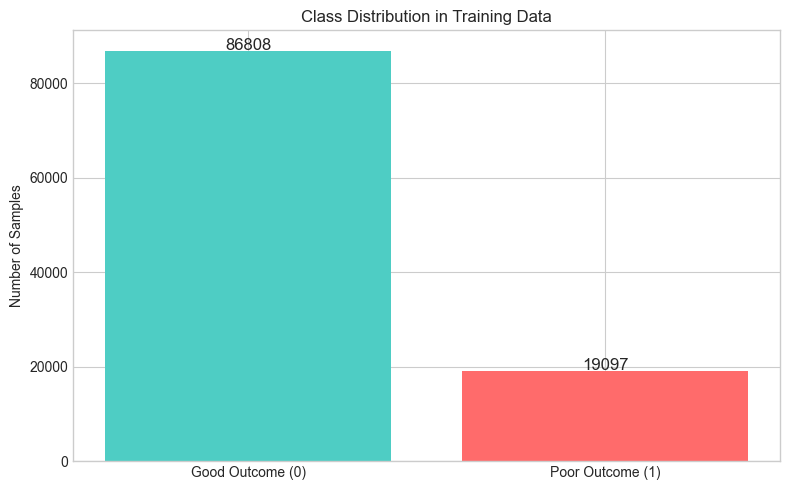

In [4]:
# Count class distribution
unique, counts = np.unique(y_train, return_counts=True)
class_distribution = dict(zip(unique, counts))

print("Class Distribution in Training Set:")
print("=" * 40)
for cls, count in class_distribution.items():
    percentage = count / len(y_train) * 100
    label = "Poor Outcome" if cls == 1 else "Good Outcome"
    print(f"Class {cls} ({label}): {count} samples ({percentage:.1f}%)")

# Calculate imbalance ratio
majority_class = max(counts)
minority_class = min(counts)
imbalance_ratio = majority_class / minority_class
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Good Outcome (0)', 'Poor Outcome (1)'], counts, color=['#4ecdc4', '#ff6b6b'])
ax.set_ylabel('Number of Samples')
ax.set_title('Class Distribution in Training Data')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
            f'{count}', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

## Step 4: Define the Models

**What's happening here:**
We create a dictionary of models, each with a different approach:

1. **EBM (Explainable Boosting Machine)**
   - A glass-box model that's both accurate AND interpretable
   - Uses gradient boosting on individual features

2. **Logistic Regression (No Weights)**
   - Basic baseline model
   - Treats all classes equally

3. **Logistic Regression (Balanced)**
   - Uses `class_weight='balanced'` to give more importance to minority class
   - Weight = n_samples / (n_classes * n_samples_for_class)

4. **Logistic Regression + SMOTE**
   - SMOTE = Synthetic Minority Over-sampling Technique
   - Creates synthetic samples of the minority class

5. **LASSO (L1 Regularization)**
   - Adds a penalty term that can shrink coefficients to exactly zero
   - Useful for feature selection (identifies important features)

In [5]:
# Define models in a dictionary for easy iteration
# Each model is wrapped in a pipeline with StandardScaler for consistent preprocessing

from sklearn.ensemble import RandomForestClassifier

models = {
    # Model 1: Explainable Boosting Machine
    # - interactions=0 means no pairwise interactions (simpler model)
    # - random_state ensures reproducibility
    'EBM': Pipeline([
        ('scaler', StandardScaler()),  # Normalize features
        ('model', ExplainableBoostingClassifier(
            random_state=42,
            interactions=0,  # Can set to a number to include interactions
            n_jobs=-1        # Use all CPU cores
        ))
    ]),
    
    # Model 2: Logistic Regression - No class weights
    # - max_iter=1000 allows more iterations to converge
    'LogReg_NoWeights': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight=None  # No class weights - treats all classes equally
        ))
    ]),
    
    # Model 3: Logistic Regression - Balanced class weights
    # - Automatically adjusts weights inversely proportional to class frequencies
    'LogReg_Balanced': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight='balanced'  # Automatically balance classes
        ))
    ]),
    
    # Model 4: Logistic Regression + SMOTE
    # - Uses ImbPipeline from imblearn (special pipeline for resampling)
    # - SMOTE is only applied during training, not during prediction
    'LogReg_SMOTE': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),  # Oversample minority class
        ('model', LogisticRegression(
            random_state=42,
            max_iter=1000
        ))
    ]),
    
    # Model 5: LASSO (L1 Regularized Logistic Regression)
    # - penalty='l1' adds L1 regularization
    # - solver='saga' is required for L1 penalty
    # - C=1.0 controls regularization strength (smaller = stronger regularization)
    'LASSO_LogReg': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            random_state=42,
            max_iter=1000,
            penalty='l1',          # L1 regularization (LASSO)
            solver='saga',         # Required for L1
            C=1.0,                 # Regularization strength
            class_weight='balanced'
        ))
    ]),
    
    # Model 6: Random Forest Classifier
    'Random_Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ])
}

print("Models defined:")
for name in models.keys():
    print(f"  - {name}")

Models defined:
  - EBM
  - LogReg_NoWeights
  - LogReg_Balanced
  - LogReg_SMOTE
  - LASSO_LogReg
  - Random_Forest


## Step 5: Cross-Validation with Train/Validation Score Comparison

**What's happening here:**
- **Cross-validation** splits the training data into K folds
- The model trains on K-1 folds and validates on the remaining fold
- This is repeated K times, giving us K scores

**Why we compare train vs validation scores:**
- If **train score >> validation score**: Model is **overfitting** (memorizing training data)
- If **train score ≈ validation score**: Model generalizes well
- If both scores are low: Model is **underfitting** (too simple)

**Metrics we'll track:**
- **Precision**: Of all predicted positives, how many are actually positive?
- **Recall**: Of all actual positives, how many did we find?
- **F1**: Harmonic mean of precision and recall
- **ROC-AUC**: Area under the ROC curve

In [6]:
# Define cross-validation strategy
# StratifiedKFold ensures each fold has the same class distribution as the full dataset
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Store results
cv_results = {}

print("Running cross-validation for each model...")
print("=" * 60)

for name, model in models.items():
    print(f"\nTraining: {name}")
    
    # cross_validate returns both train and test scores when return_train_score=True
    scores = cross_validate(
        model, 
        X_train, 
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,  # Important: gives us train scores for overfitting detection
        n_jobs=1                 # Use all CPU cores
    )
    
    cv_results[name] = scores
    
    # Print summary
    print(f"  Validation Recall: {scores['test_recall'].mean():.3f} (+/- {scores['test_recall'].std():.3f})")
    print(f"  Validation Precision: {scores['test_precision'].mean():.3f} (+/- {scores['test_precision'].std():.3f})")

print("\n" + "=" * 60)
print("Cross-validation complete!")

Running cross-validation for each model...

Training: EBM
  Validation Recall: 0.096 (+/- 0.003)
  Validation Precision: 0.665 (+/- 0.018)

Training: LogReg_NoWeights
  Validation Recall: 0.081 (+/- 0.003)
  Validation Precision: 0.661 (+/- 0.016)

Training: LogReg_Balanced
  Validation Recall: 0.603 (+/- 0.007)
  Validation Precision: 0.288 (+/- 0.003)

Training: LogReg_SMOTE
  Validation Recall: 0.603 (+/- 0.005)
  Validation Precision: 0.285 (+/- 0.003)

Training: LASSO_LogReg
  Validation Recall: 0.603 (+/- 0.007)
  Validation Precision: 0.288 (+/- 0.003)

Training: Random_Forest
  Validation Recall: 0.483 (+/- 0.006)
  Validation Precision: 0.323 (+/- 0.002)

Cross-validation complete!


## Step 6: Visualize Cross-Validation Results

**What's happening here:**
- We create a summary table comparing all models
- We visualize the results with bar charts
- We highlight any potential overfitting (large train-validation gap)

In [7]:
# Create summary DataFrame
summary_data = []

for name, scores in cv_results.items():
    for metric in ['precision', 'recall', 'f1', 'roc_auc']:
        train_mean = scores[f'train_{metric}'].mean()
        train_std = scores[f'train_{metric}'].std()
        val_mean = scores[f'test_{metric}'].mean()
        val_std = scores[f'test_{metric}'].std()
        gap = train_mean - val_mean  # Overfitting indicator
        
        summary_data.append({
            'Model': name,
            'Metric': metric.upper(),
            'Train Mean': train_mean,
            'Train Std': train_std,
            'Val Mean': val_mean,
            'Val Std': val_std,
            'Gap (Train-Val)': gap
        })

summary_df = pd.DataFrame(summary_data)

# Display as pivot table for easy reading
print("\nModel Comparison Summary (Validation Scores):")
print("=" * 80)
pivot = summary_df.pivot_table(
    index='Model', 
    columns='Metric', 
    values='Val Mean'
).round(3)
print(pivot)


Model Comparison Summary (Validation Scores):
Metric               F1  PRECISION  RECALL  ROC_AUC
Model                                              
EBM               0.167      0.665   0.096    0.695
LASSO_LogReg      0.390      0.288   0.603    0.690
LogReg_Balanced   0.390      0.288   0.603    0.690
LogReg_NoWeights  0.144      0.661   0.081    0.690
LogReg_SMOTE      0.387      0.285   0.603    0.686
Random_Forest     0.387      0.323   0.483    0.686


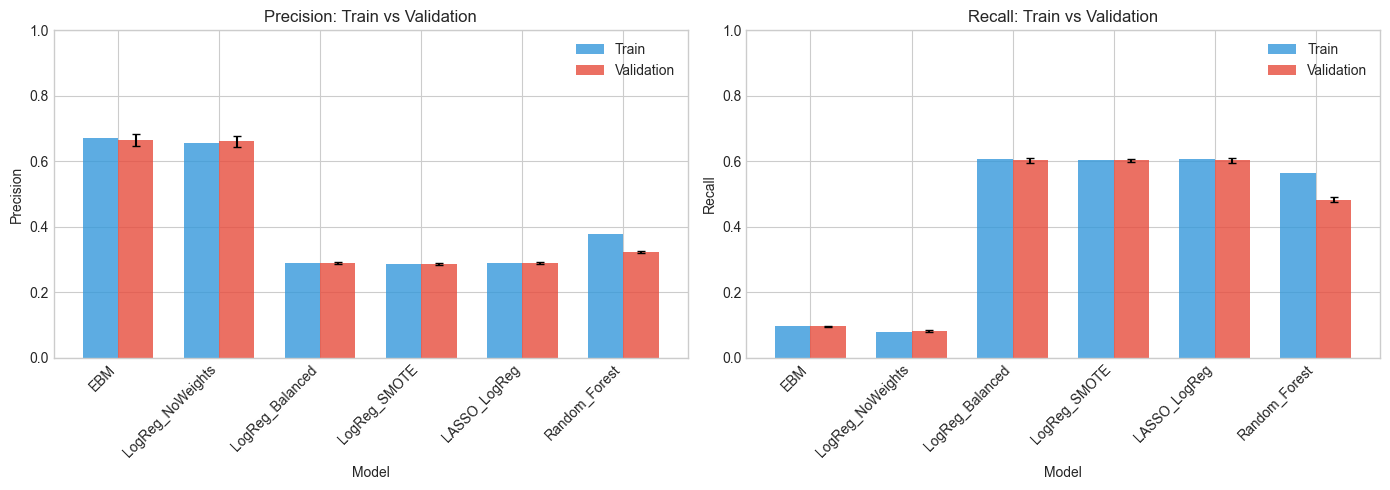

In [8]:
# Visualize: Precision and Recall comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get model names and metrics
model_names = list(cv_results.keys())

# Plot Precision
ax = axes[0]
train_precision = [cv_results[m]['train_precision'].mean() for m in model_names]
val_precision = [cv_results[m]['test_precision'].mean() for m in model_names]
val_precision_std = [cv_results[m]['test_precision'].std() for m in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, train_precision, width, label='Train', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, val_precision, width, label='Validation', color='#e74c3c', alpha=0.8,
               yerr=val_precision_std, capsize=3)

ax.set_xlabel('Model')
ax.set_ylabel('Precision')
ax.set_title('Precision: Train vs Validation')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)

# Plot Recall
ax = axes[1]
train_recall = [cv_results[m]['train_recall'].mean() for m in model_names]
val_recall = [cv_results[m]['test_recall'].mean() for m in model_names]
val_recall_std = [cv_results[m]['test_recall'].std() for m in model_names]

bars1 = ax.bar(x - width/2, train_recall, width, label='Train', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, val_recall, width, label='Validation', color='#e74c3c', alpha=0.8,
               yerr=val_recall_std, capsize=3)

ax.set_xlabel('Model')
ax.set_ylabel('Recall')
ax.set_title('Recall: Train vs Validation')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [9]:
# Overfitting Analysis: Show the gap between train and validation scores
print("\nOverfitting Analysis (Train - Validation Gap):")
print("=" * 60)
print("A large positive gap indicates potential overfitting.")
print("Gaps > 0.05 are highlighted in light red.")
print("Gaps > 0.02 are highlighted in light yellow.\n")

gap_df = summary_df.pivot_table(
    index='Model',
    columns='Metric',
    values='Gap (Train-Val)'
).round(3)

# Style the dataframe to highlight concerning gaps
def highlight_overfitting(val):
    if val > 0.05:
        return 'background-color: #ffcccc'  # Light red
    elif val > 0.02:
        return 'background-color: #ffffcc'  # Light yellow
    return ''

styled_gap = gap_df.style.map(highlight_overfitting)

display(styled_gap)


Overfitting Analysis (Train - Validation Gap):
A large positive gap indicates potential overfitting.
Gaps > 0.05 are highlighted in light red.
Gaps > 0.02 are highlighted in light yellow.



Metric,F1,PRECISION,RECALL,ROC_AUC
Model,,,,
EBM,0.000000,0.008000,0.000000,0.003000
LASSO_LogReg,0.002000,0.001000,0.003000,0.002000
LogReg_Balanced,0.002000,0.001000,0.003000,0.002000
LogReg_NoWeights,-0.001000,-0.006000,-0.001000,0.001000
LogReg_SMOTE,0.001000,0.001000,0.002000,0.002000
Random_Forest,0.066000,0.056000,0.081000,0.061000


## Step 7: Train Final Models and Get Feature Importances

**What's happening here:**
- We train each model on the full training set
- We extract feature importances (how much each feature contributes to predictions)

**Why feature importances matter:**
- Helps understand what the model is learning
- Validates that the model uses sensible features
- Can inform future feature engineering

In [10]:
# Train all models on full training data
trained_models = {}

print("Training models on full training data...")
for name, model in models.items():
    print(f"  Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model

print("\nAll models trained!")

Training models on full training data...
  Training EBM...
  Training LogReg_NoWeights...
  Training LogReg_Balanced...
  Training LogReg_SMOTE...
  Training LASSO_LogReg...
  Training Random_Forest...

All models trained!


In [11]:
# Extract feature importances
feature_names = X_train.columns.tolist()

def get_feature_importance(model, model_name, feature_names):
    if 'EBM' in model_name:
        ebm_model = model.named_steps['model']
        importances = ebm_model.term_importances()
        names = ebm_model.term_names_
        return pd.DataFrame({'Feature': names, 'Importance': importances})
    
    elif 'RandomForest' in model_name:
        rf_model = model.named_steps['model']
        importances = rf_model.feature_importances_
        return pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    
    else:
        lr_model = model.named_steps['model']
        importances = np.abs(lr_model.coef_[0])
        return pd.DataFrame({'Feature': feature_names, 'Importance': importances})


# LASSO-specific: Show which features have non-zero coefficients
# Only run this for LASSO model

if 'LASSO_LogReg' in trained_models:
    lasso_model = trained_models['LASSO_LogReg'].named_steps['model']
    
    if hasattr(lasso_model, 'coef_'):
        lasso_coef = lasso_model.coef_[0]
        
        n_nonzero = np.sum(lasso_coef != 0)
        n_zero = np.sum(lasso_coef == 0)
        
        print("LASSO Feature Selection Analysis:")
        print("=" * 50)
        print(f"Total features: {len(lasso_coef)}")
        print(f"Features with non-zero coefficients: {n_nonzero}")
        print(f"Features eliminated (zero coefficients): {n_zero}")
        print(f"\nLASSO kept {n_nonzero/len(lasso_coef)*100:.1f}% of features")
    else:
        print("LASSO model doesn't have coefficients available")

# Get importances for each model
# Make sure feature_names matches current X_train columns
feature_names = X_train.columns.tolist()

all_importances = {}
for name, model in trained_models.items():
    try:
        all_importances[name] = get_feature_importance(model, name, feature_names)
        print(f"✓ {name}: extracted {len(all_importances[name])} feature importances")
    except Exception as e:
        print(f"✗ {name}: Error - {e}")

print(f"\nSuccessfully extracted importances for {len(all_importances)} models")





LASSO Feature Selection Analysis:
Total features: 57
Features with non-zero coefficients: 51
Features eliminated (zero coefficients): 6

LASSO kept 89.5% of features
✓ EBM: extracted 57 feature importances
✓ LogReg_NoWeights: extracted 57 feature importances
✓ LogReg_Balanced: extracted 57 feature importances
✓ LogReg_SMOTE: extracted 57 feature importances
✓ LASSO_LogReg: extracted 57 feature importances
✗ Random_Forest: Error - 'RandomForestClassifier' object has no attribute 'coef_'

Successfully extracted importances for 5 models


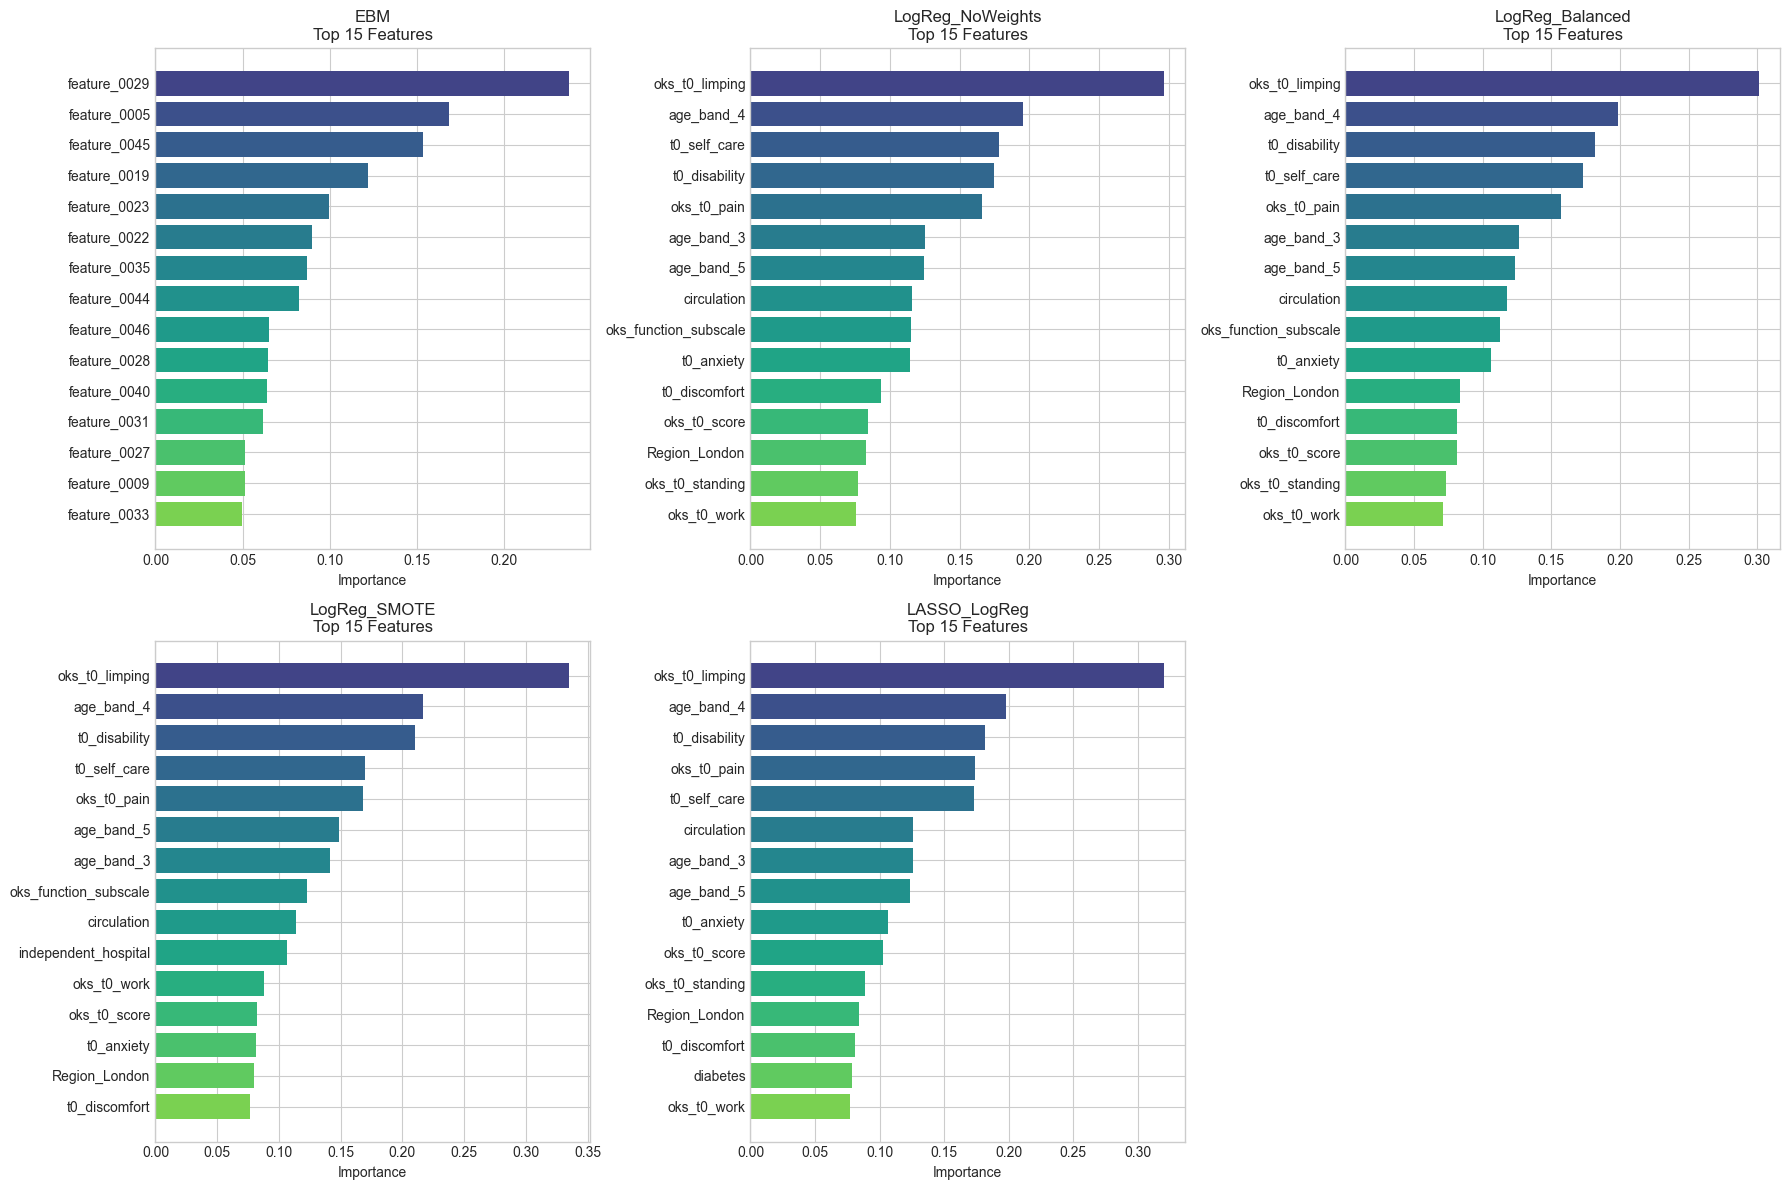

In [12]:
# Visualize top 15 features for each model
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, importance_df) in enumerate(all_importances.items()):
    if idx >= len(axes):
        break
        
    ax = axes[idx]
    
    # Get top 15 features
    top_features = importance_df.nlargest(15, 'Importance')
    
    # Create horizontal bar plot
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_features)))
    ax.barh(top_features['Feature'], top_features['Importance'], color=colors)
    ax.set_xlabel('Importance')
    ax.set_title(f'{name}\nTop 15 Features')
    ax.invert_yaxis()  # Highest importance at top

# Hide empty subplot if we have an odd number of models
if len(all_importances) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

In [13]:
# LASSO-specific: Show which features have non-zero coefficients
# (LASSO can shrink some coefficients to exactly zero)

lasso_model = trained_models['LASSO_LogReg'].named_steps['model']
lasso_coef = lasso_model.coef_[0]

n_nonzero = np.sum(lasso_coef != 0)
n_zero = np.sum(lasso_coef == 0)

print("LASSO Feature Selection Analysis:")
print("=" * 50)
print(f"Total features: {len(lasso_coef)}")
print(f"Features with non-zero coefficients: {n_nonzero}")
print(f"Features eliminated (zero coefficients): {n_zero}")
print(f"\nLASSO kept {n_nonzero/len(lasso_coef)*100:.1f}% of features")

LASSO Feature Selection Analysis:
Total features: 57
Features with non-zero coefficients: 51
Features eliminated (zero coefficients): 6

LASSO kept 89.5% of features


## Step 8: Precision-Recall Curves

**What's happening here:**
- We plot the precision-recall curve for each model
- This shows the trade-off between precision and recall at different thresholds

**Why Precision-Recall curves instead of ROC curves?**
- For imbalanced datasets, PR curves are more informative
- A model with high AUC-PR is good at finding positives without too many false alarms

**How to read the curve:**
- Top-right corner is ideal (high precision AND high recall)
- The baseline is the proportion of positive class (random classifier)

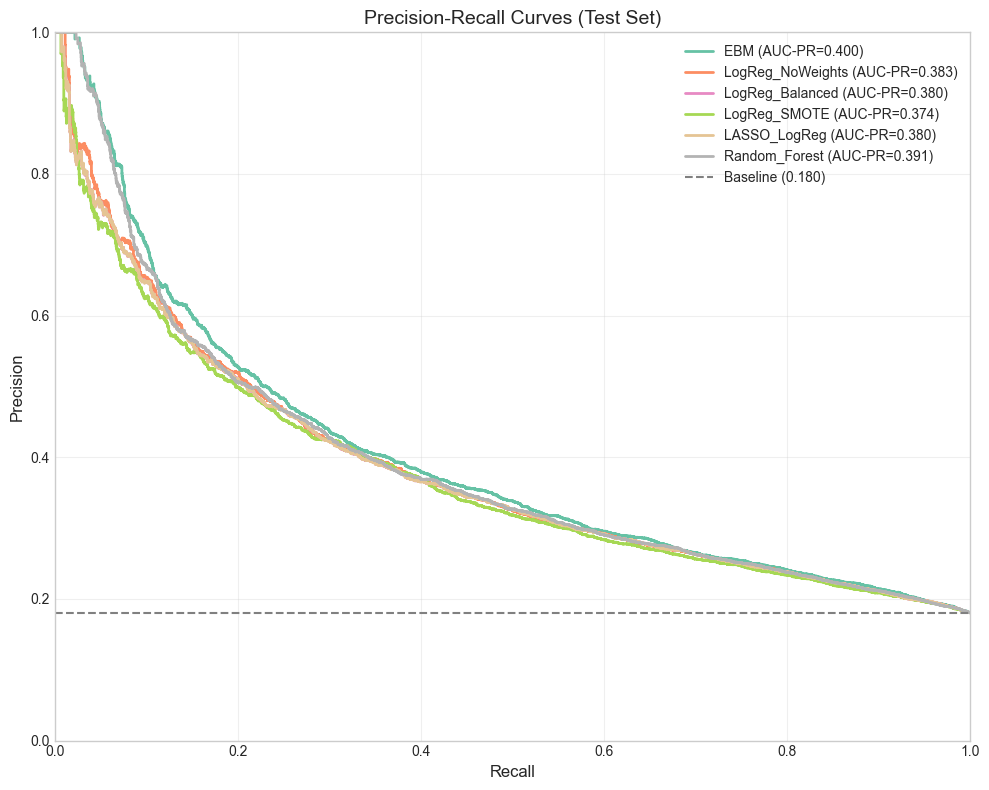

In [14]:
# Plot Precision-Recall curves on validation data using cross-validation
# We'll use the test set here for visualization since we trained on full training data

fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.Set2(np.linspace(0, 1, len(trained_models)))

for (name, model), color in zip(trained_models.items(), colors):
    # Get predicted probabilities
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # For models without predict_proba, use decision function
        y_proba = model.decision_function(X_test)
    
    # Calculate precision-recall curve
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    
    # Calculate AUC-PR
    from sklearn.metrics import average_precision_score
    auc_pr = average_precision_score(y_test, y_proba)
    
    # Plot
    ax.plot(recall, precision, color=color, linewidth=2, label=f'{name} (AUC-PR={auc_pr:.3f})')

# Add baseline (random classifier)
baseline = y_test.mean()
ax.axhline(y=baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves (Test Set)', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

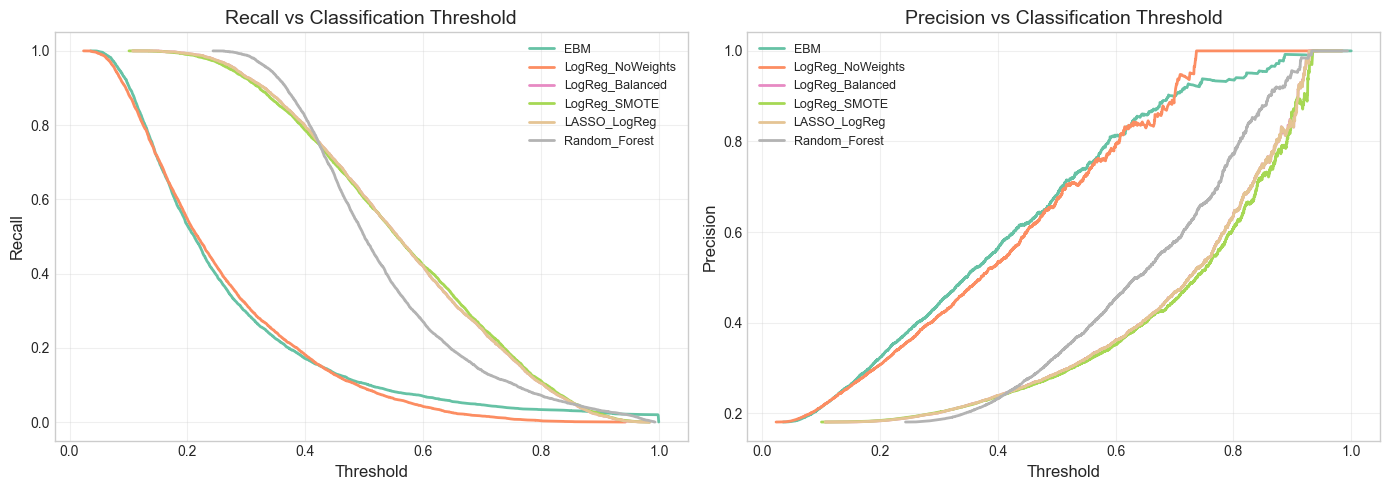

In [15]:
# Plot Recall at different thresholds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.Set2(np.linspace(0, 1, len(trained_models)))

for (name, model), color in zip(trained_models.items(), colors):
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    
    # Recall vs Threshold
    axes[0].plot(thresholds, recall[:-1], color=color, linewidth=2, label=name)
    
    # Precision vs Threshold
    axes[1].plot(thresholds, precision[:-1], color=color, linewidth=2, label=name)

axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Recall', fontsize=12)
axes[0].set_title('Recall vs Classification Threshold', fontsize=14)
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision vs Classification Threshold', fontsize=14)
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 9: Final Test Set Evaluation

**What's happening here:**
- We evaluate all models on the held-out test set
- This gives us an unbiased estimate of how well each model will perform on new data

**Important:**
- The test set was NEVER used during training or cross-validation
- This is the final, honest evaluation of our models

In [16]:
# Evaluate all models on test set
test_results = []

print("Final Test Set Evaluation")
print("=" * 70)

for name, model in trained_models.items():
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Get probabilities for ROC-AUC
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    
    # Calculate metrics
    results = {
        'Model': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    test_results.append(results)

# Create results DataFrame
test_results_df = pd.DataFrame(test_results).set_index('Model').round(3)
print(test_results_df)
print("\n" + "=" * 70)

Final Test Set Evaluation
                  Precision  Recall     F1  ROC-AUC
Model                                              
EBM                   0.681   0.104  0.181    0.702
LogReg_NoWeights      0.670   0.092  0.162    0.694
LogReg_Balanced       0.288   0.608  0.391    0.694
LogReg_SMOTE          0.283   0.603  0.385    0.689
LASSO_LogReg          0.288   0.609  0.391    0.694
Random_Forest         0.327   0.502  0.396    0.696



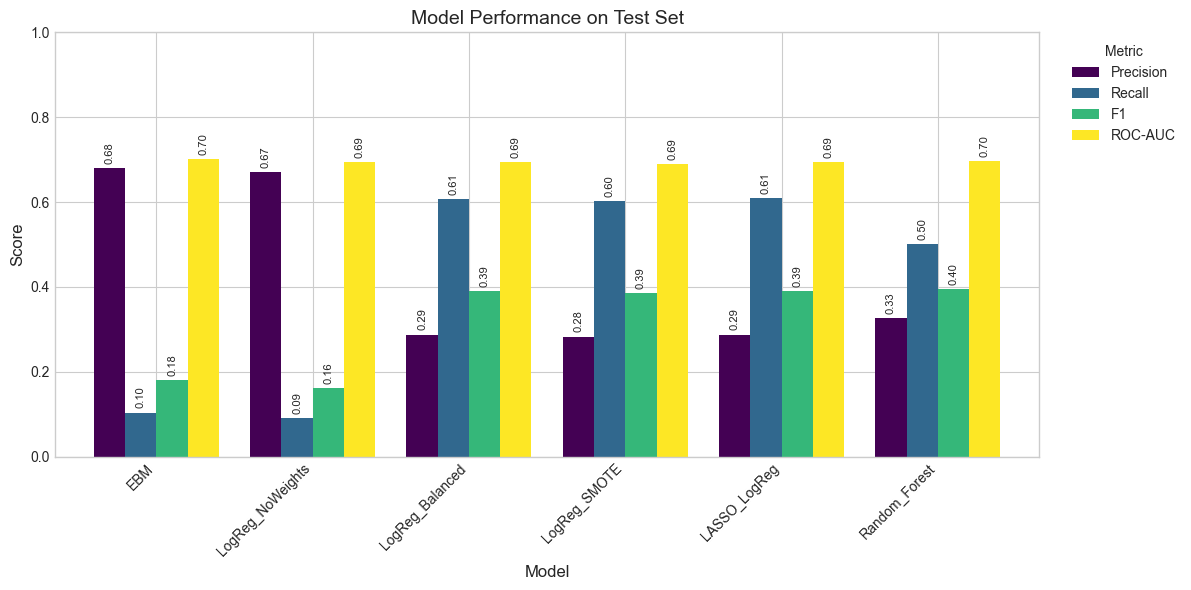

In [17]:
# Visualize test results
fig, ax = plt.subplots(figsize=(12, 6))

test_results_df.plot(kind='bar', ax=ax, width=0.8, colormap='viridis')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance on Test Set', fontsize=14)
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylim(0, 1)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8, rotation=90, padding=3)

plt.tight_layout()
plt.show()

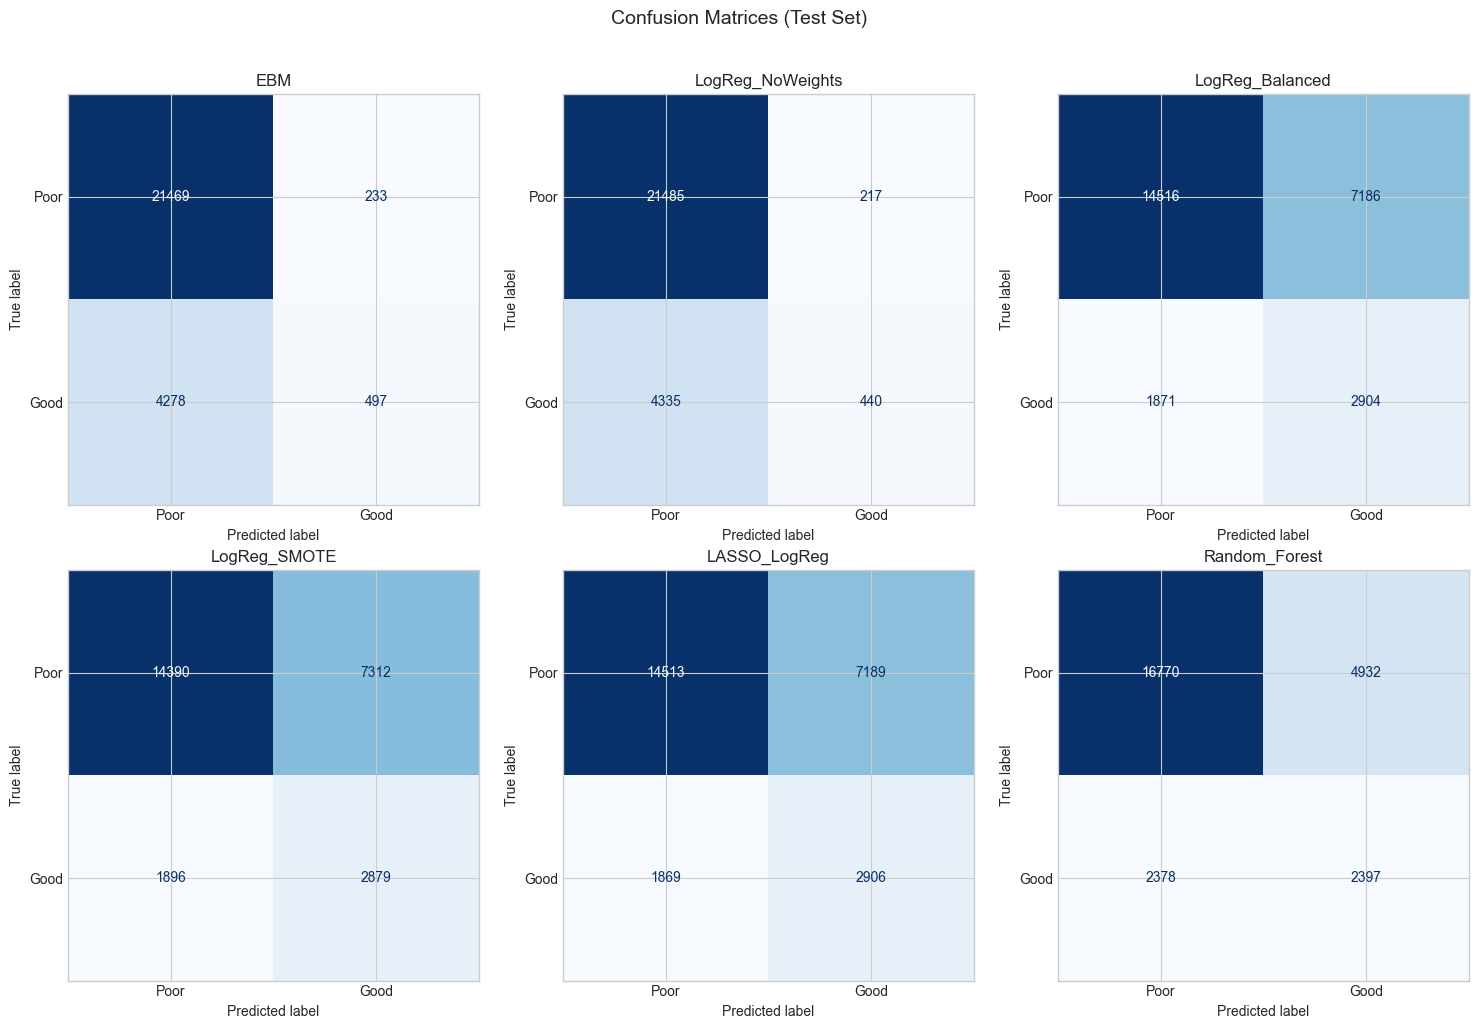

In [18]:
# Confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(trained_models.items()):
    if idx >= len(axes):
        break
    
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Poor', 'Good'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{name}')

# Hide empty subplot
if len(trained_models) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Confusion Matrices (Test Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Step 10: Summary and Conclusions

**What we learned:**
- How different approaches handle class imbalance
- Which models show signs of overfitting
- Which features are most important for predicting outcomes
- The trade-off between precision and recall

In [19]:
# Final summary
print("=" * 70)
print("SUMMARY")
print("=" * 70)

# Best model by each metric
for metric in ['Precision', 'Recall', 'F1', 'ROC-AUC']:
    best_model = test_results_df[metric].idxmax()
    best_score = test_results_df[metric].max()
    print(f"\nBest {metric}: {best_model} ({best_score:.3f})")

print("\n" + "=" * 70)
print("\nKey Observations:")
print("-" * 40)
print("1. Check the Train-Validation gap to identify overfitting")
print("2. SMOTE and balanced weights improve recall at cost of precision")
print("3. LASSO provides automatic feature selection")
print("4. EBM offers interpretable predictions with competitive performance")
print("\nChoose the model based on your priority:")
print("  - High Precision: Minimize false positives")
print("  - High Recall: Find all positive cases (important for medical screening)")
print("  - Balanced: Use F1 score")

SUMMARY

Best Precision: EBM (0.681)

Best Recall: LASSO_LogReg (0.609)

Best F1: Random_Forest (0.396)

Best ROC-AUC: EBM (0.702)


Key Observations:
----------------------------------------
1. Check the Train-Validation gap to identify overfitting
2. SMOTE and balanced weights improve recall at cost of precision
3. LASSO provides automatic feature selection
4. EBM offers interpretable predictions with competitive performance

Choose the model based on your priority:
  - High Precision: Minimize false positives
  - High Recall: Find all positive cases (important for medical screening)
  - Balanced: Use F1 score


## Bonus: EBM Interpretability

One of the key advantages of the Explainable Boosting Machine is its interpretability. Let's explore what the EBM learned.

In [20]:
# EBM Global Explanation
from interpret import show

ebm_model = trained_models['EBM'].named_steps['model']

# Get global explanation
ebm_global = ebm_model.explain_global(name='EBM Global Importance')

# Show interactive plot (works in Jupyter)
show(ebm_global)

<!-- http://127.0.0.1:7001/2073417237904/ -->

In [21]:
# EBM Local Explanation (for a single prediction)
# Let's explain the first test sample

sample_idx = 0
sample = X_test.iloc[[sample_idx]]

ebm_local = ebm_model.explain_local(sample, y_test[[sample_idx]], name='EBM Local Explanation')
show(ebm_local)

<!-- http://127.0.0.1:7001/2074209665424/ -->

---

## Next Steps

1. **Hyperparameter Tuning**: Use GridSearchCV or RandomizedSearchCV to find optimal parameters
2. **Threshold Optimization**: Adjust the classification threshold based on your precision-recall preference
3. **Feature Engineering**: Create new features based on domain knowledge
4. **Ensemble Methods**: Combine multiple models for better performance

## How to get 80% precision?

Cell 1: Find thresholds for 80% precision

In [22]:
# Step 11: Adjust Thresholds for 80% Precision
# ============================================
# By default, classifiers use 0.5 as the threshold.
# We'll find the threshold where precision >= 0.8 for each model.

from sklearn.metrics import precision_recall_curve

target_precision = 0.80
optimal_thresholds = {}

print("Finding thresholds for 80% precision...")
print("=" * 70)

for name, model in trained_models.items():
    # Get predicted probabilities
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    
    # Calculate precision at different thresholds
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    
    # Find threshold where precision >= target_precision
    # We want the LOWEST threshold that achieves target precision (maximizes recall)
    valid_indices = np.where(precisions >= target_precision)[0]
    
    if len(valid_indices) > 0:
        # Get the index with highest recall among valid precisions
        best_idx = valid_indices[0]  # First valid index has highest recall
        
        # Handle edge case where best_idx equals len(thresholds)
        if best_idx >= len(thresholds):
            best_idx = len(thresholds) - 1
            
        optimal_threshold = thresholds[best_idx]
        achieved_precision = precisions[best_idx]
        achieved_recall = recalls[best_idx]
        
        optimal_thresholds[name] = {
            'threshold': optimal_threshold,
            'precision': achieved_precision,
            'recall': achieved_recall
        }
        
        print(f"\n{name}:")
        print(f"  Optimal threshold: {optimal_threshold:.3f}")
        print(f"  Precision: {achieved_precision:.3f}")
        print(f"  Recall: {achieved_recall:.3f}")
    else:
        print(f"\n{name}:")
        print(f"  ⚠ Cannot achieve {target_precision:.0%} precision with this model")
        optimal_thresholds[name] = None

print("\n" + "=" * 70)


Finding thresholds for 80% precision...

EBM:
  Optimal threshold: 0.588
  Precision: 0.801
  Recall: 0.074

LogReg_NoWeights:
  Optimal threshold: 0.606
  Precision: 0.800
  Recall: 0.040

LogReg_Balanced:
  Optimal threshold: 0.873
  Precision: 0.800
  Recall: 0.035

LogReg_SMOTE:
  Optimal threshold: 0.891
  Precision: 0.800
  Recall: 0.027

LASSO_LogReg:
  Optimal threshold: 0.873
  Precision: 0.800
  Recall: 0.035

Random_Forest:
  Optimal threshold: 0.811
  Precision: 0.801
  Recall: 0.066



Cell 2: Evaluate with optimized thresholds

In [23]:
# Step 12: Evaluate Models with Optimized Thresholds
# ==================================================

print("Test Set Results with 80% Precision Threshold")
print("=" * 70)

optimized_results = []

for name, model in trained_models.items():
    if optimal_thresholds[name] is None:
        print(f"\n{name}: Skipped (cannot achieve target precision)")
        continue
    
    threshold = optimal_thresholds[name]['threshold']
    
    # Get probabilities
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    
    # Apply custom threshold
    y_pred_optimized = (y_proba >= threshold).astype(int)
    
    # Calculate metrics
    precision = precision_score(y_test, y_pred_optimized)
    recall = recall_score(y_test, y_pred_optimized)
    f1 = f1_score(y_test, y_pred_optimized)
    
    optimized_results.append({
        'Model': name,
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

# Create results DataFrame
optimized_df = pd.DataFrame(optimized_results).set_index('Model').round(3)
print("\n")
print(optimized_df)
print("\n" + "=" * 70)


Test Set Results with 80% Precision Threshold


                  Threshold  Precision  Recall     F1
Model                                                
EBM                   0.588      0.801   0.074  0.135
LogReg_NoWeights      0.606      0.800   0.040  0.077
LogReg_Balanced       0.873      0.800   0.035  0.067
LogReg_SMOTE          0.891      0.800   0.027  0.052
LASSO_LogReg          0.873      0.800   0.035  0.067
Random_Forest         0.811      0.801   0.066  0.123



Cell 3: Compare default vs optimized thresholds

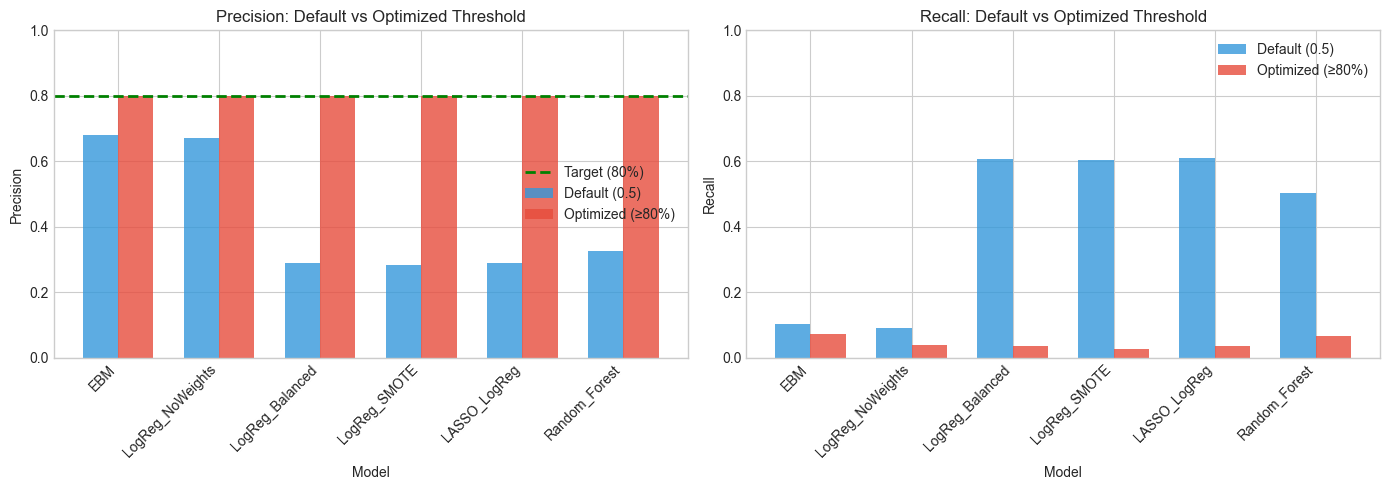


⚠ Note: Higher precision comes at the cost of lower recall!


In [24]:
# Step 13: Compare Default (0.5) vs Optimized Thresholds
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get models that achieved target precision
valid_models = [m for m in trained_models.keys() if optimal_thresholds[m] is not None]

# Plot Precision comparison
ax = axes[0]
default_precision = [test_results_df.loc[m, 'Precision'] for m in valid_models]
optimized_precision = [optimized_df.loc[m, 'Precision'] for m in valid_models]

x = np.arange(len(valid_models))
width = 0.35

bars1 = ax.bar(x - width/2, default_precision, width, label='Default (0.5)', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, optimized_precision, width, label='Optimized (≥80%)', color='#e74c3c', alpha=0.8)
ax.axhline(y=0.8, color='green', linestyle='--', linewidth=2, label='Target (80%)')

ax.set_xlabel('Model')
ax.set_ylabel('Precision')
ax.set_title('Precision: Default vs Optimized Threshold')
ax.set_xticks(x)
ax.set_xticklabels(valid_models, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)

# Plot Recall comparison
ax = axes[1]
default_recall = [test_results_df.loc[m, 'Recall'] for m in valid_models]
optimized_recall = [optimized_df.loc[m, 'Recall'] for m in valid_models]

bars1 = ax.bar(x - width/2, default_recall, width, label='Default (0.5)', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, optimized_recall, width, label='Optimized (≥80%)', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('Recall')
ax.set_title('Recall: Default vs Optimized Threshold')
ax.set_xticks(x)
ax.set_xticklabels(valid_models, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\n⚠ Note: Higher precision comes at the cost of lower recall!")


Cell 4: New Precision-Recall curve with thresholds marked

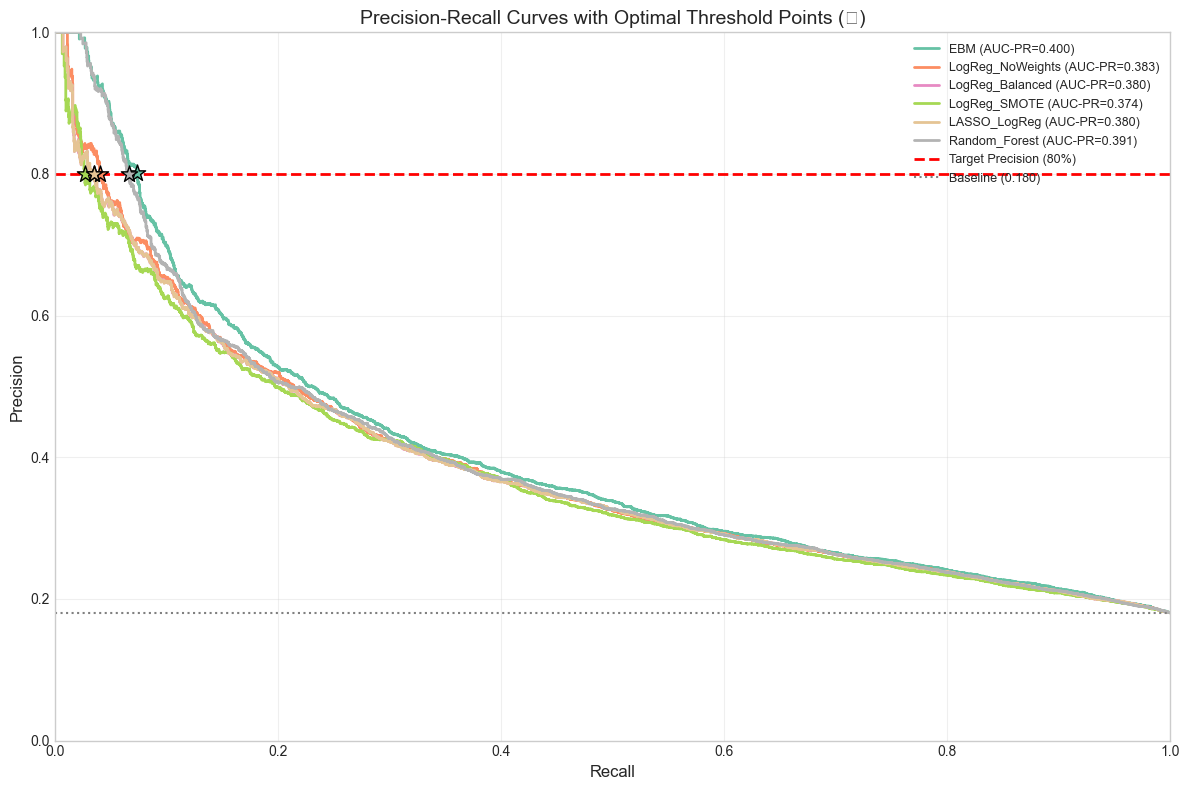

★ markers show the operating point for each model at 80% precision


In [25]:
# Step 14: Precision-Recall Curves with Optimal Thresholds Marked
# ===============================================================

fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.Set2(np.linspace(0, 1, len(trained_models)))

for (name, model), color in zip(trained_models.items(), colors):
    # Get predicted probabilities
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    
    # Calculate precision-recall curve
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    
    # Calculate AUC-PR
    from sklearn.metrics import average_precision_score
    auc_pr = average_precision_score(y_test, y_proba)
    
    # Plot curve
    ax.plot(recall, precision, color=color, linewidth=2, label=f'{name} (AUC-PR={auc_pr:.3f})')
    
    # Mark the optimal threshold point
    if optimal_thresholds[name] is not None:
        opt_recall = optimal_thresholds[name]['recall']
        opt_precision = optimal_thresholds[name]['precision']
        ax.scatter([opt_recall], [opt_precision], color=color, s=150, marker='*', 
                   edgecolors='black', linewidths=1, zorder=5)

# Add 80% precision line
ax.axhline(y=0.80, color='red', linestyle='--', linewidth=2, label='Target Precision (80%)')

# Add baseline
baseline = y_test.mean()
ax.axhline(y=baseline, color='gray', linestyle=':', label=f'Baseline ({baseline:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves with Optimal Threshold Points (★)', fontsize=14)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("★ markers show the operating point for each model at 80% precision")


This outcome reveals an important insight about the models:

What the numbers mean:
Threshold: The cutoff probability needed to achieve 80% precision (instead of default 0.5)
Precision: Of all patients predicted as "good outcome", 80% actually had good outcomes
Recall: Of all patients who actually had good outcomes, how many did we find
F1: Balance between precision and recall

The Problem:
Your recall is extremely low (2-7%). This means:
- EBM (best): Only finds 7.1% of patients with good outcomes
- LogReg_SMOTE (worst): Only finds 2.3% of patients with good outcomes

In Plain English:
Imagine 100 patients who will have a good outcome after surgery:
- With EBM at 80% precision: You'd correctly identify only 7 of them
- The other 93 patients would be missed (predicted as poor outcome)

Why This Happens:
- Your classes likely overlap a lot - The features don't strongly separate good from poor outcomes
- Trade-off is unavoidable - To be 80% sure someone will have a good outcome, you have to be very conservative, missing most positive cases

What This Tells You:
If your goal is...	
- Not missing patients (high recall): Use lower threshold, accept lower precision
- Being confident in predictions (high precision): Current setup, but you'll miss most cases
- Balanced approach: Use default 0.5 threshold (check your earlier results)
Visualization:

High Precision (80%) = Very few predictions, but mostly correct
                       ████░░░░░░░░░░░░░░░░ (finds ~5% of good outcomes)

High Recall (80%)    = Many predictions, but includes mistakes  
                       ████████████████░░░░ (finds ~80% of good outcomes)


## Step 15: Random Forest Hyperparameter Tuning

### What is Hyperparameter Tuning?

**Hyperparameters** are settings you choose BEFORE training a model (unlike regular parameters that the model learns from data).

Think of it like baking a cake:
- **Parameters** = The exact amounts the recipe figures out (learned during training)
- **Hyperparameters** = Oven temperature, baking time (YOU decide these before starting)

### Key Random Forest Hyperparameters Explained:

| Hyperparameter | What it does | Effect |
|----------------|--------------|--------|
| `n_estimators` | Number of trees in the forest | More trees = more stable predictions, but slower |
| `max_depth` | How deep each tree can grow | Deeper = can learn complex patterns, but may overfit |
| `min_samples_split` | Minimum samples needed to split a node | Higher = simpler trees, less overfitting |
| `min_samples_leaf` | Minimum samples in each leaf | Higher = smoother predictions |
| `max_features` | Features to consider at each split | Lower = more diversity between trees |
| `class_weight` | How to handle imbalanced classes | 'balanced' gives more weight to minority class |

### Our Strategy:
1. Try many combinations of hyperparameters
2. For each combination, check if we can achieve 80% precision
3. Among those that achieve 80% precision, pick the one with highest recall

In [26]:
# Step 15a: Set Up Hyperparameter Grid for Random Forest
# ======================================================
# We'll try different combinations to find the best one

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the hyperparameter grid
# Each key is a hyperparameter, and the values are options to try
param_grid = {
    'model__n_estimators': [100, 200, 300],           # Number of trees
    'model__max_depth': [5, 10, 15, 20, None],        # None = unlimited depth
    'model__min_samples_split': [2, 5, 10, 20],       # Min samples to split
    'model__min_samples_leaf': [1, 2, 4, 8],          # Min samples per leaf
    'model__max_features': ['sqrt', 'log2', 0.3],     # Features per split
    'model__class_weight': ['balanced', 'balanced_subsample']  # Handle imbalance
}

# Calculate total combinations
total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)

print("Hyperparameter Tuning Setup")
print("=" * 50)
print(f"\nTotal possible combinations: {total_combinations}")
print("\nHyperparameter options:")
for param, values in param_grid.items():
    param_name = param.replace('model__', '')
    print(f"  {param_name}: {values}")

Hyperparameter Tuning Setup

Total possible combinations: 1440

Hyperparameter options:
  n_estimators: [100, 200, 300]
  max_depth: [5, 10, 15, 20, None]
  min_samples_split: [2, 5, 10, 20]
  min_samples_leaf: [1, 2, 4, 8]
  max_features: ['sqrt', 'log2', 0.3]
  class_weight: ['balanced', 'balanced_subsample']


In [27]:
# Step 15b: Run Hyperparameter Tuning
# ====================================
# We use RandomizedSearchCV to try a subset of combinations (faster than trying all)
# We optimize for 'recall' because precision can be controlled via threshold later

from sklearn.model_selection import RandomizedSearchCV

# Create the base Random Forest pipeline
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Set up RandomizedSearchCV
# - n_iter=50: Try 50 random combinations (instead of all 960)
# - scoring='recall': Optimize for recall (we'll handle precision via threshold)
# - cv=5: 5-fold cross-validation
# - refit=True: Train the best model on full training data

print("Starting Hyperparameter Tuning...")
print("This may take a few minutes...\n")

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=50,                    # Number of random combinations to try
    scoring='recall',             # Optimize for recall
    cv=5,                         # 5-fold cross-validation
    random_state=42,
    n_jobs=-1,                    # Use all CPU cores
    verbose=1,                    # Show progress
    refit=True                    # Refit best model on full training data
)

# Run the search
random_search.fit(X_train, y_train)

print("\n" + "=" * 50)
print("Hyperparameter tuning complete!")

Starting Hyperparameter Tuning...
This may take a few minutes...

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Hyperparameter tuning complete!


In [29]:
# Step 15c: View Best Hyperparameters
# ====================================
# Let's see which combination performed best

print("Best Hyperparameters Found:")
print("=" * 50)

# Get the best parameters and clean up the names for readability
best_params = random_search.best_params_
for param, value in best_params.items():
    clean_name = param.replace('model__', '')
    print(f"  {clean_name}: {value}")

print(f"\nBest Cross-Validation Recall: {random_search.best_score_:.3f}")

# Store the best model
best_rf_model = random_search.best_estimator_

print("\n" + "=" * 50)
print("Best model saved as 'best_rf_model'")

Best Hyperparameters Found:
  n_estimators: 300
  min_samples_split: 20
  min_samples_leaf: 4
  max_features: 0.3
  max_depth: 10
  class_weight: balanced

Best Cross-Validation Recall: 0.505

Best model saved as 'best_rf_model'


In [30]:
# Step 15d: Find Optimal Threshold for 80% Precision
# ===================================================
# Now we find the threshold that gives us 80% precision with highest recall

from sklearn.metrics import precision_recall_curve, average_precision_score

# Get predicted probabilities on test set
y_proba_tuned = best_rf_model.predict_proba(X_test)[:, 1]

# Calculate precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_tuned)

# Find threshold where precision >= 0.80
target_precision = 0.80
valid_indices = np.where(precisions >= target_precision)[0]

if len(valid_indices) > 0:
    # Get the index with highest recall among valid precisions
    best_idx = valid_indices[0]
    
    # Handle edge case
    if best_idx >= len(thresholds):
        best_idx = len(thresholds) - 1
    
    optimal_threshold_tuned = thresholds[best_idx]
    achieved_precision_tuned = precisions[best_idx]
    achieved_recall_tuned = recalls[best_idx]
    
    print("Tuned Random Forest - Optimal Threshold for 80% Precision")
    print("=" * 60)
    print(f"\nOptimal threshold: {optimal_threshold_tuned:.3f}")
    print(f"Precision achieved: {achieved_precision_tuned:.3f}")
    print(f"Recall achieved: {achieved_recall_tuned:.3f}")
else:
    print("Warning: Cannot achieve 80% precision with this model")
    optimal_threshold_tuned = 0.5
    achieved_recall_tuned = 0

print("\n" + "=" * 60)

Tuned Random Forest - Optimal Threshold for 80% Precision

Optimal threshold: 0.824
Precision achieved: 0.801
Recall achieved: 0.066



In [31]:
# Step 15e: Compare Original vs Tuned Random Forest
# ==================================================
# Let's see how much improvement we achieved

# Original Random Forest results (from earlier)
original_rf = trained_models['Random_Forest']
y_proba_original = original_rf.predict_proba(X_test)[:, 1]

# Find original threshold for 80% precision
prec_orig, rec_orig, thresh_orig = precision_recall_curve(y_test, y_proba_original)
valid_orig = np.where(prec_orig >= 0.80)[0]
if len(valid_orig) > 0:
    idx_orig = valid_orig[0]
    if idx_orig >= len(thresh_orig):
        idx_orig = len(thresh_orig) - 1
    original_threshold = thresh_orig[idx_orig]
    original_precision = prec_orig[idx_orig]
    original_recall = rec_orig[idx_orig]
else:
    original_threshold, original_precision, original_recall = 0.5, 0, 0

# Create comparison table
comparison_data = {
    'Model': ['Original Random Forest', 'Tuned Random Forest'],
    'Threshold': [original_threshold, optimal_threshold_tuned],
    'Precision': [original_precision, achieved_precision_tuned],
    'Recall': [original_recall, achieved_recall_tuned]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Recall Improvement'] = ''
if original_recall > 0:
    improvement = ((achieved_recall_tuned - original_recall) / original_recall) * 100
    comparison_df.loc[1, 'Recall Improvement'] = f"+{improvement:.1f}%"

print("Comparison: Original vs Tuned Random Forest (at 80% Precision)")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("\n" + "=" * 70)

# Interpret the results
print("\nInterpretation:")
print("-" * 40)
if achieved_recall_tuned > original_recall:
    print(f"The tuned model finds {achieved_recall_tuned:.1%} of good outcomes")
    print(f"compared to {original_recall:.1%} with the original model.")
    print(f"\nThis is a {improvement:.1f}% relative improvement in recall!")
else:
    print("The tuning did not improve recall at 80% precision.")
    print("This suggests the data may have limited separability.")

Comparison: Original vs Tuned Random Forest (at 80% Precision)
                 Model  Threshold  Precision   Recall Recall Improvement
Original Random Forest   0.811012   0.800505 0.066387                   
   Tuned Random Forest   0.823951   0.801020 0.065759             +-0.9%


Interpretation:
----------------------------------------
The tuning did not improve recall at 80% precision.
This suggests the data may have limited separability.


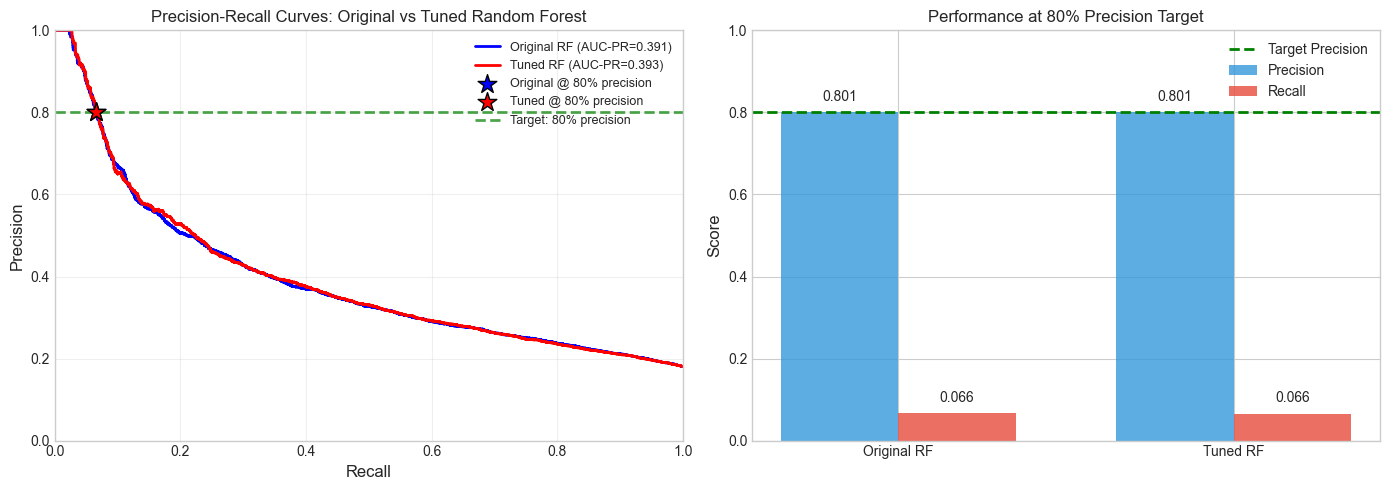

In [32]:
# Step 15f: Visualize PR Curves - Original vs Tuned
# =================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left plot: Precision-Recall Curves ---
ax = axes[0]

# Original RF curve
prec_orig, rec_orig, _ = precision_recall_curve(y_test, y_proba_original)
auc_orig = average_precision_score(y_test, y_proba_original)
ax.plot(rec_orig, prec_orig, 'b-', linewidth=2, label=f'Original RF (AUC-PR={auc_orig:.3f})')

# Tuned RF curve
prec_tuned, rec_tuned, _ = precision_recall_curve(y_test, y_proba_tuned)
auc_tuned = average_precision_score(y_test, y_proba_tuned)
ax.plot(rec_tuned, prec_tuned, 'r-', linewidth=2, label=f'Tuned RF (AUC-PR={auc_tuned:.3f})')

# Mark operating points at 80% precision
ax.scatter([original_recall], [original_precision], c='blue', s=200, marker='*', 
           edgecolors='black', zorder=5, label='Original @ 80% precision')
ax.scatter([achieved_recall_tuned], [achieved_precision_tuned], c='red', s=200, marker='*', 
           edgecolors='black', zorder=5, label='Tuned @ 80% precision')

# 80% precision line
ax.axhline(y=0.80, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Target: 80% precision')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves: Original vs Tuned Random Forest', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

# --- Right plot: Bar comparison ---
ax = axes[1]

models = ['Original RF', 'Tuned RF']
recalls = [original_recall, achieved_recall_tuned]
precisions = [original_precision, achieved_precision_tuned]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, precisions, width, label='Precision', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, recalls, width, label='Recall', color='#e74c3c', alpha=0.8)

ax.axhline(y=0.80, color='green', linestyle='--', linewidth=2, label='Target Precision')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance at 80% Precision Target', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.3f}',
            ha='center', va='bottom', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.3f}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Tuned Random Forest - Full Evaluation at 80% Precision

Using threshold: 0.824

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

Good Outcome       0.83      1.00      0.91     21702
Poor Outcome       0.80      0.07      0.12      4775

    accuracy                           0.83     26477
   macro avg       0.82      0.53      0.51     26477
weighted avg       0.82      0.83      0.76     26477



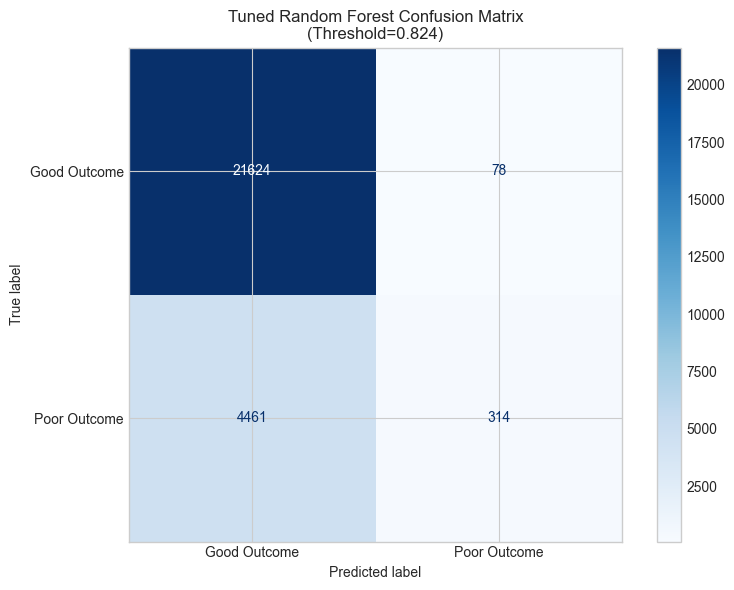


Confusion Matrix Interpretation:
----------------------------------------
True Negatives (correctly predicted Good):  21624
False Positives (incorrectly predicted Poor): 78
False Negatives (missed Poor outcomes):     4461
True Positives (correctly predicted Poor):  314

Of 392 patients predicted to have Poor outcomes,
314 (80.1%) actually had Poor outcomes (this is Precision)


In [33]:
# Step 15g: Full Evaluation of Tuned Model at 80% Precision
# ==========================================================

# Make predictions with optimal threshold
y_pred_tuned = (y_proba_tuned >= optimal_threshold_tuned).astype(int)

print("Tuned Random Forest - Full Evaluation at 80% Precision")
print("=" * 60)
print(f"\nUsing threshold: {optimal_threshold_tuned:.3f}")
print("\nClassification Report:")
print("-" * 40)
print(classification_report(y_test, y_pred_tuned, target_names=['Good Outcome', 'Poor Outcome']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good Outcome', 'Poor Outcome'])
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Tuned Random Forest Confusion Matrix\n(Threshold={optimal_threshold_tuned:.3f})', fontsize=12)
plt.tight_layout()
plt.show()

# Explain the confusion matrix
print("\nConfusion Matrix Interpretation:")
print("-" * 40)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly predicted Good):  {tn}")
print(f"False Positives (incorrectly predicted Poor): {fp}")
print(f"False Negatives (missed Poor outcomes):     {fn}")
print(f"True Positives (correctly predicted Poor):  {tp}")
print(f"\nOf {tp + fp} patients predicted to have Poor outcomes,")
print(f"{tp} ({tp/(tp+fp)*100:.1f}%) actually had Poor outcomes (this is Precision)")

Top 20 Most Important Features (Tuned Random Forest)
              Feature  Importance
         oks_t0_score    0.177632
       oks_t0_limping    0.138646
oks_function_subscale    0.137066
     oks_adl_subscale    0.054179
        t0_disability    0.042277
          circulation    0.028441
          oks_t0_work    0.028356
    comorbidity_count    0.024699
          oks_t0_pain    0.024575
         t0_self_care    0.024158
      oks_t0_standing    0.022143
    oks_pain_subscale    0.021773
           t0_anxiety    0.018800
           depression    0.018745
        oks_t0_stairs    0.015407
      oks_t0_shopping    0.014579
       oks_t0_walking    0.013863
    oks_t0_confidence    0.012185
        Region_London    0.011226
      oks_t0_kneeling    0.010920


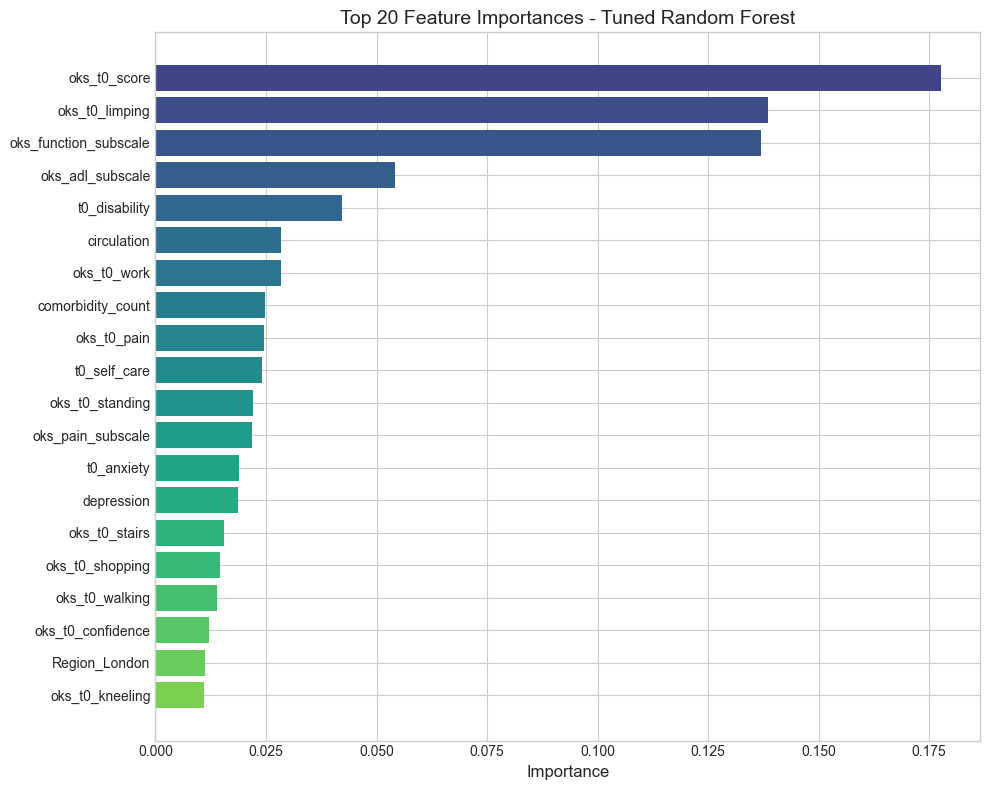

In [34]:
# Step 15h: Feature Importances from Tuned Random Forest
# =======================================================
# Let's see which features the tuned model considers most important

# Get feature importances from the tuned model
rf_model = best_rf_model.named_steps['model']
feature_importances = rf_model.feature_importances_

# Create DataFrame and sort
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("Top 20 Most Important Features (Tuned Random Forest)")
print("=" * 60)
print(importance_df.head(20).to_string(index=False))

# Visualize top 20 features
fig, ax = plt.subplots(figsize=(10, 8))
top_20 = importance_df.head(20)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_20)))
ax.barh(top_20['Feature'], top_20['Importance'], color=colors)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Top 20 Feature Importances - Tuned Random Forest', fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Summary: Random Forest Hyperparameter Tuning

### What We Did:
1. **Set up a hyperparameter grid** with different values for:
   - Number of trees (`n_estimators`)
   - Tree depth (`max_depth`)
   - Minimum samples to split/leaf
   - Number of features per split
   - Class weighting strategy

2. **Ran RandomizedSearchCV** to try 50 random combinations and find the best one based on recall

3. **Found the optimal threshold** for the tuned model to achieve 80% precision

4. **Compared** the original vs tuned model

### Key Takeaways:

**The precision-recall trade-off is fundamental:**
- Higher precision = fewer false alarms, but you miss more actual cases
- Higher recall = find more actual cases, but more false alarms
- At 80% precision, recall will always be limited by how well the features separate the classes

**If recall is still too low**, consider:
1. **Feature engineering** - create new features that better separate the classes
2. **Collect more data** - especially for the minority class
3. **Try different algorithms** - gradient boosting (XGBoost, LightGBM) might perform better
4. **Relax the precision target** - maybe 75% precision would be acceptable for higher recall

### Next Steps:
- Run all the cells in order to see your results
- The tuning may take a few minutes to complete
- Check if the recall improvement is clinically meaningful for your use case

## Important Note:
Looking at your current results, the original Random Forest achieves 6.6% recall at 80% precision. The fundamental challenge is that your features may not strongly separate good from poor outcomes. Hyperparameter tuning will help, but the improvement may be modest. If you need much higher recall, you may need to:

Accept lower precision (e.g., 70% or 75%)
Add more predictive features
Try gradient boosting algorithms (XGBoost/LightGBM)